# Exercise 09 — Inheritance: PolyGon, Rectangle

NUMA01 VT2026 — Arvid Brenner & Sixten Midsem

Lösningar till `exercise09.md`. Bygger en abstrakt klass `PolyGon`,
en konkret `Rectangle`, och en `SpecialRectangle` med axelparallella
sidor + `__contains__`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Task 1 — Abstrakt klass `PolyGon`

`__init__` tar en lista av hörnpunkter (varje `(2,)`-array) och beräknar
kantlistan. `plot` ritar polygonen genom att förbinda kanterna. Vi lägger
också den sista kanten tillbaka till första hörnet så polygonen blir
sluten.


In [2]:
class PolyGon:
    """Abstrakt polygon. Förvarar hörn och kanter, kan rita sig själv."""

    def __init__(self, corners):
        self.corners = [np.asarray(c, dtype=float) for c in corners]
        # kant i = (corner_i, corner_{i+1 mod n})
        n = len(self.corners)
        self.edges = [(self.corners[i], self.corners[(i + 1) % n])
                      for i in range(n)]

    def plot(self, ax=None, **kwargs):
        if ax is None:
            ax = plt.gca()
        for p, q in self.edges:
            ax.plot([p[0], q[0]], [p[1], q[1]], **kwargs)
        ax.set_aspect('equal')
        return ax


## Task 2 — `Rectangle`

Ärver från `PolyGon`. Tar fyra hörn (i ordning runt rektangeln) och
beräknar arean ur de två första kantlängderna.


In [3]:
class Rectangle(PolyGon):
    def __init__(self, corners):
        if len(corners) != 4:
            raise ValueError("En rektangel har exakt 4 hörn")
        super().__init__(corners)

    def area(self):
        # längd av två angränsande sidor
        a = np.linalg.norm(self.edges[0][1] - self.edges[0][0])
        b = np.linalg.norm(self.edges[1][1] - self.edges[1][0])
        return a * b


# enkel rektangel 3x2
R = Rectangle([(0, 0), (3, 0), (3, 2), (0, 2)])
print("Area:", R.area())   # 6


Area: 6.0


## Task 3 — `SpecialRectangle` (axelparallell)

Konstrueras smidigast från två motsatta hörn (nedre vänster, övre höger).
Vi exponerar dessutom `xmin/xmax/ymin/ymax` för senare bruk i
`__contains__`.


In [4]:
class SpecialRectangle(Rectangle):
    """Rektangel med kanter parallella med axlarna. Konstrueras med två
    motsatta hörn (lower-left, upper-right)."""

    def __init__(self, lower_left, upper_right):
        x0, y0 = lower_left
        x1, y1 = upper_right
        if x0 > x1 or y0 > y1:
            raise ValueError("lower_left måste ha mindre x och y än upper_right")
        corners = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]
        super().__init__(corners)
        self.xmin, self.ymin = x0, y0
        self.xmax, self.ymax = x1, y1

    # Task 4
    def __contains__(self, other):
        """`other in self` är True om other ⊆ self (båda axelparallella)."""
        if not isinstance(other, SpecialRectangle):
            raise TypeError("__contains__ kräver en SpecialRectangle")
        return (self.xmin <= other.xmin and other.xmax <= self.xmax and
                self.ymin <= other.ymin and other.ymax <= self.ymax)


## Task 4 — Test av `__contains__`

`A in B` ⇔ A är helt innesluten i B.


A_inside in B : True
A_outside in B: False
A_equal in B  : True


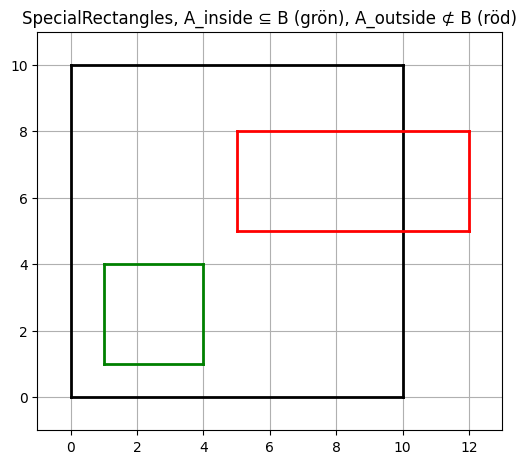

In [5]:
B = SpecialRectangle((0, 0), (10, 10))
A_inside  = SpecialRectangle((1, 1), (4, 4))     # ⊆ B
A_outside = SpecialRectangle((5, 5), (12, 8))    # sticker ut
A_equal   = SpecialRectangle((0, 0), (10, 10))   # = B (räknas som ⊆)

print("A_inside in B :", A_inside in B)    # True
print("A_outside in B:", A_outside in B)   # False
print("A_equal in B  :", A_equal in B)     # True

# Visa det grafiskt
fig, ax = plt.subplots(figsize=(6, 6))
B.plot(ax=ax, color='black', lw=2)
A_inside.plot(ax=ax, color='green', lw=2)
A_outside.plot(ax=ax, color='red', lw=2)
ax.set_xlim(-1, 13); ax.set_ylim(-1, 11)
ax.grid(True); ax.set_title('SpecialRectangles, A_inside ⊆ B (grön), A_outside ⊄ B (röd)')
plt.show()


## Bonus — generell PolyGon-rit-test


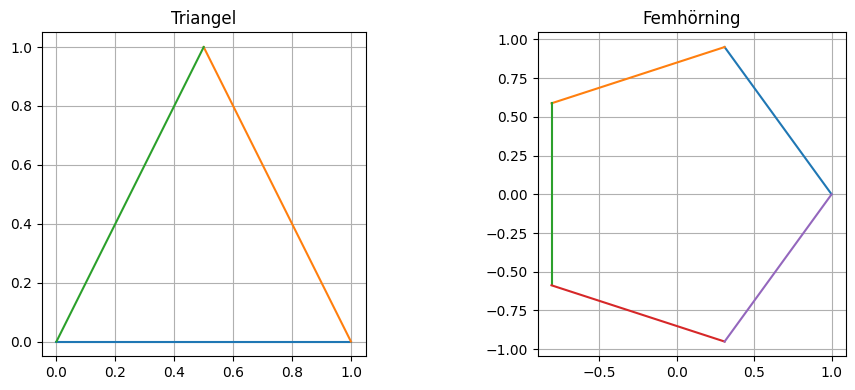

In [6]:
# Triangel + femhörning som demo för basklassen
triangle = PolyGon([(0, 0), (1, 0), (0.5, 1)])
pentagon = PolyGon([(np.cos(t), np.sin(t)) for t in np.linspace(0, 2*np.pi, 6)[:-1]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
triangle.plot(ax=axes[0]); axes[0].set_title('Triangel')
pentagon.plot(ax=axes[1]); axes[1].set_title('Femhörning')
for a in axes: a.grid(True)
plt.tight_layout(); plt.show()
